In [4]:
import sklearn
iris = sklearn.datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [10]:
iris = sklearn.datasets.load_iris()
print(type(iris.data))
print(iris.data.shape)
print(iris.feature_names)
print(iris.target_names)
print(iris.data[:5])

<class 'numpy.ndarray'>
(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [11]:
print(iris.data.mean(axis=0))

[5.84333333 3.05733333 3.758      1.19933333]


In [17]:
mean = iris.data.std(axis=0)
for k, v in zip(iris.feature_names, mean):
    print('{:17} : {:3.2f}'.format(k, v))

sepal length (cm) : 0.83
sepal width (cm)  : 0.43
petal length (cm) : 1.76
petal width (cm)  : 0.76


### Emperical rule: 68-95-99 rule
5th to 95th percentile of data contains most significant data

In [18]:
import numpy as np
print(np.percentile(iris.data, q=[5, 95]))

[0.2 6.7]


what is the species having max sepal length

In [19]:
print(i:=iris.data[:, 0].argmax())
print(iris.data[i])
print(t:=iris.target[i])
print(iris.target_names[t])

131
[7.9 3.8 6.4 2. ]
2
virginica


separate mean of each section

In [21]:
s1 = iris.data[iris.target == 0].mean(axis=0)
s2 = iris.data[iris.target == 1].mean(axis=0)
s3 = iris.data[iris.target == 2].mean(axis=0)
mean = iris.data.mean(axis=0)
print(' '*19, *iris.target_names)
for k, v1, v2, v3 in zip(iris.feature_names, s1, s2, s3):
    print('%-17s : %3.2f %6.2f %10.2f'%(k, v1, v2, v3))

                    setosa versicolor virginica
sepal length (cm) : 5.01   5.94       6.59
sepal width (cm)  : 3.43   2.77       2.97
petal length (cm) : 1.46   4.26       5.55
petal width (cm)  : 0.25   1.33       2.03


In [27]:
import pandas as pd
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print(df)
print(df.describe())

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
       sepal length (cm)  sepal width (c

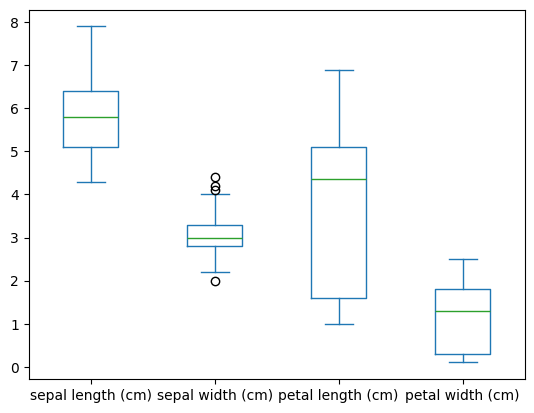

In [28]:
import matplotlib.pyplot as plt
ax = df.plot.box().get_figure()
plt.show()

array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>]], dtype=object)

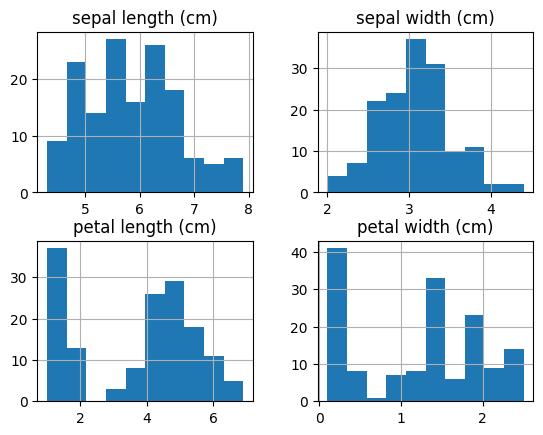

In [29]:
df.hist()

array([[<Axes: xlabel='sep-l', ylabel='sep-l'>,
        <Axes: xlabel='sep-w', ylabel='sep-l'>,
        <Axes: xlabel='pet-l', ylabel='sep-l'>,
        <Axes: xlabel='pet-w', ylabel='sep-l'>],
       [<Axes: xlabel='sep-l', ylabel='sep-w'>,
        <Axes: xlabel='sep-w', ylabel='sep-w'>,
        <Axes: xlabel='pet-l', ylabel='sep-w'>,
        <Axes: xlabel='pet-w', ylabel='sep-w'>],
       [<Axes: xlabel='sep-l', ylabel='pet-l'>,
        <Axes: xlabel='sep-w', ylabel='pet-l'>,
        <Axes: xlabel='pet-l', ylabel='pet-l'>,
        <Axes: xlabel='pet-w', ylabel='pet-l'>],
       [<Axes: xlabel='sep-l', ylabel='pet-w'>,
        <Axes: xlabel='sep-w', ylabel='pet-w'>,
        <Axes: xlabel='pet-l', ylabel='pet-w'>,
        <Axes: xlabel='pet-w', ylabel='pet-w'>]], dtype=object)

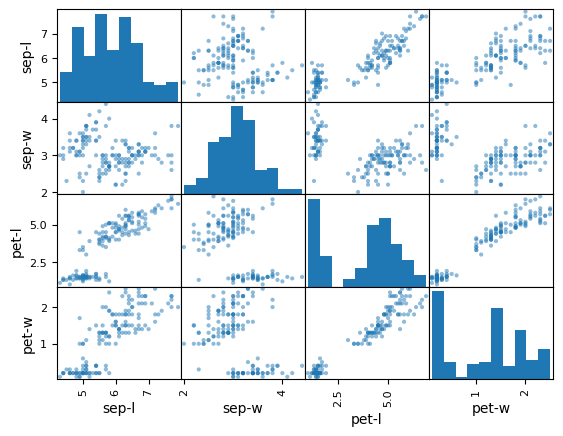

In [32]:
df.columns = [ 'sep-l', 'sep-w', 'pet-l', 'pet-w']
pd.plotting.scatter_matrix(df)

array([[<Axes: xlabel='sep-l', ylabel='sep-l'>,
        <Axes: xlabel='sep-w', ylabel='sep-l'>],
       [<Axes: xlabel='sep-l', ylabel='sep-w'>,
        <Axes: xlabel='sep-w', ylabel='sep-w'>]], dtype=object)

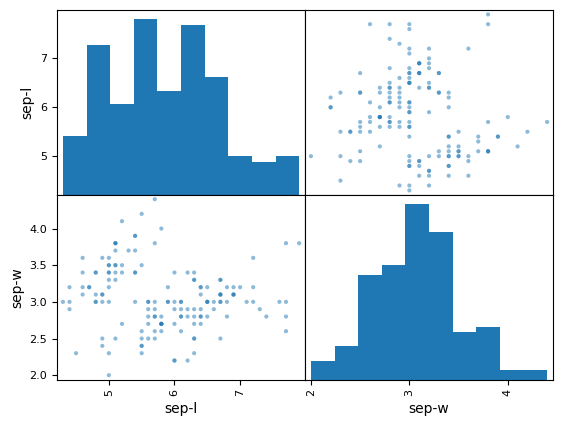

In [33]:
pd.plotting.scatter_matrix(df[['sep-l', 'sep-w']])

add target to dataset

In [42]:
df['target'] = iris.target
df.groupby('target').mean()

,sep-l,sep-w,pet-l,pet-w
target,,,,
0,5.006,3.428,1.462,0.246
1,5.936,2.770,4.260,1.326
2,6.588,2.974,5.552,2.026


In [45]:
df['species'] = list(map(lambda x: iris.target_names[x], iris.target))
print(df)

     sep-l  sep-w  pet-l  pet-w  target    species
0      5.1    3.5    1.4    0.2       0     setosa
1      4.9    3.0    1.4    0.2       0     setosa
2      4.7    3.2    1.3    0.2       0     setosa
3      4.6    3.1    1.5    0.2       0     setosa
4      5.0    3.6    1.4    0.2       0     setosa
..     ...    ...    ...    ...     ...        ...
145    6.7    3.0    5.2    2.3       2  virginica
146    6.3    2.5    5.0    1.9       2  virginica
147    6.5    3.0    5.2    2.0       2  virginica
148    6.2    3.4    5.4    2.3       2  virginica
149    5.9    3.0    5.1    1.8       2  virginica

[150 rows x 6 columns]


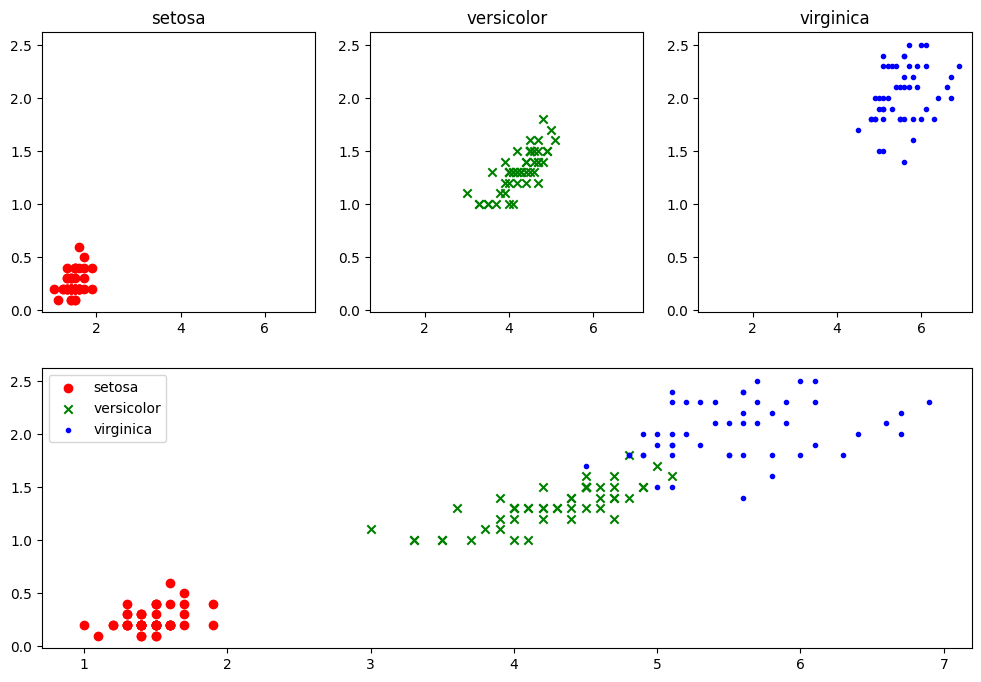

In [60]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])  # 2 rows, 3 columns

# First row: 3 individual scatter plots
# First subplot (used for sharing x and y)
ax0 = fig.add_subplot(gs[0, 0])
axes = [ax0, fig.add_subplot(gs[0, 1], sharex=ax0, sharey=ax0), fig.add_subplot(gs[0, 2], sharex=ax0, sharey=ax0)]
# Create the next two with shared axes

# Second row: 1 plot spanning all 3 columns
ax_bottom = fig.add_subplot(gs[1, :])

col = ['red', 'green', 'blue']
mark = ['o', 'x', '.']

for i, (name, group) in enumerate(df.groupby('species')):
    axes[i].scatter(group['pet-l'], group['pet-w'], color=col[i], marker=mark[i])
    axes[i].set_title(name)
    ax_bottom.scatter(group['pet-l'], group['pet-w'], color=col[i], marker=mark[i], label=name)
ax_bottom.legend()